# Langsmith
- langsmith는 langchain에서 만든 온라인 기반의 LLM 애플리케이션 모니터링, 테스트 지원, 배포 지원 도구이다.

## [Concepts](https://docs.smith.langchain.com/observability/concepts)
- 이 개념 가이드는 LangSmith에 추적 로그를 기록할 때 이해해야 할 중요한 주제를 다룹니다.
- Trace는 애플리케이션이 입력에서 출력으로 가는 일련의 단계를 의미합니다. 이 각각의 개별 단계는 Run으로 표현됩니다.
- Project는 단순히 여러 개의 Trace 모음입니다.

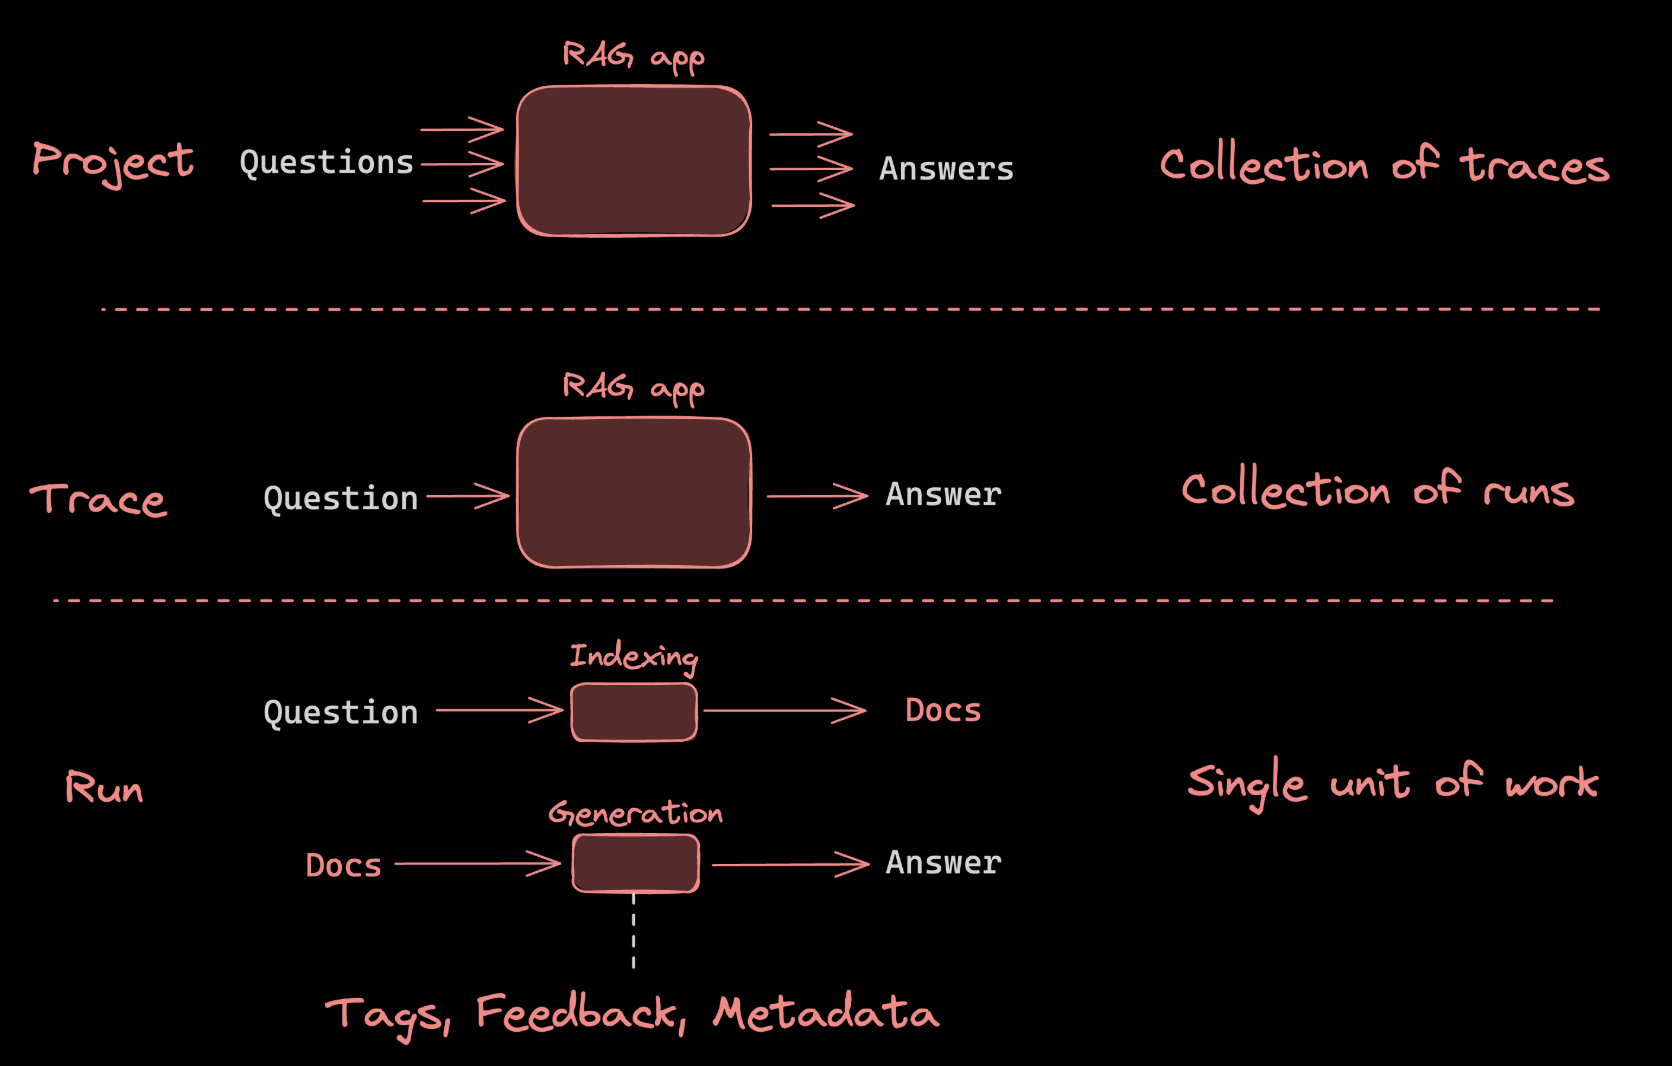

### Projects
- Project는 여러 Trace의 모음입니다.
- 프로젝트는 단일 애플리케이션이나 서비스와 관련된 모든 Trace를 담는 컨테이너로 생각할 수 있습니다.
- 여러 개의 프로젝트를 가질 수 있으며, 각 프로젝트는 여러 Trace를 포함할 수 있습니다.

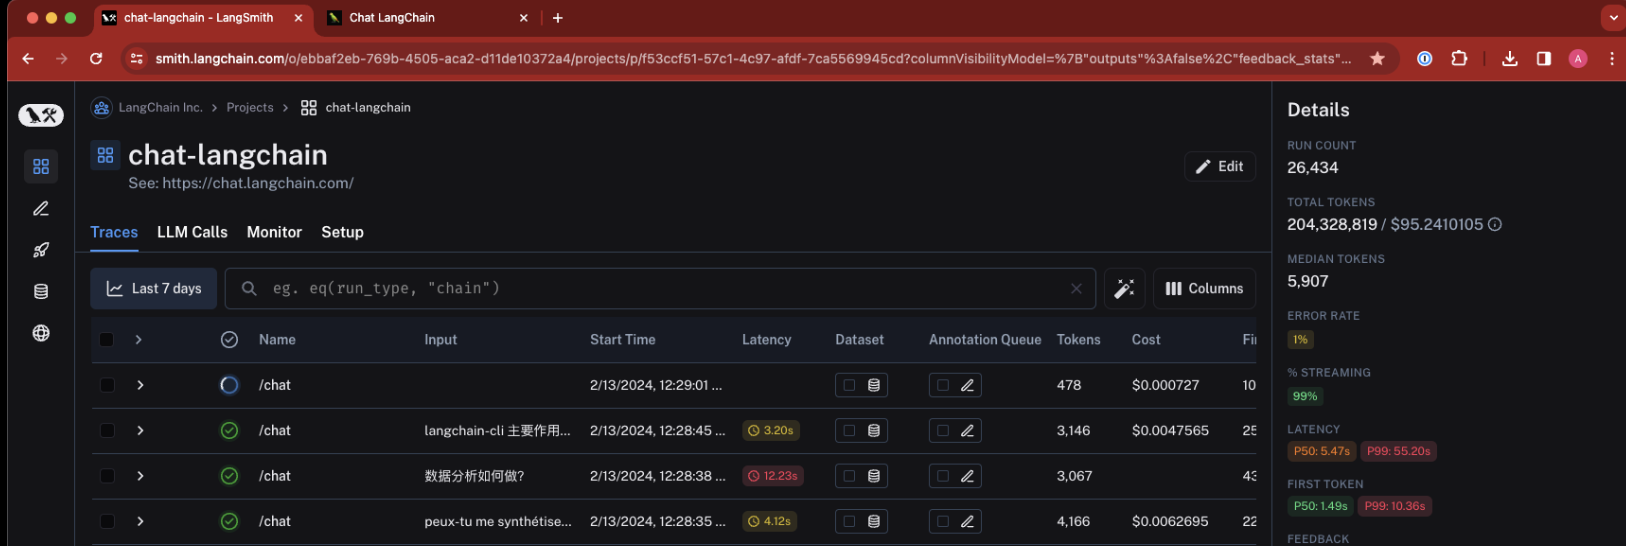

### Trace
- Trace는 단일 작업과 관련된 여러 Run의 모음입니다.
- 예를 들어, 사용자 요청이 체인을 트리거하고, 그 체인이 LLM에 대한 호출을 하고, 이후 출력 파서를 호출하는 등의 작업을 한다면, 이러한 모든 Run은 동일한 Trace의 일부가 됩니다.
- Run은 고유한 Trace ID에 의해 Trace에 묶입니다.

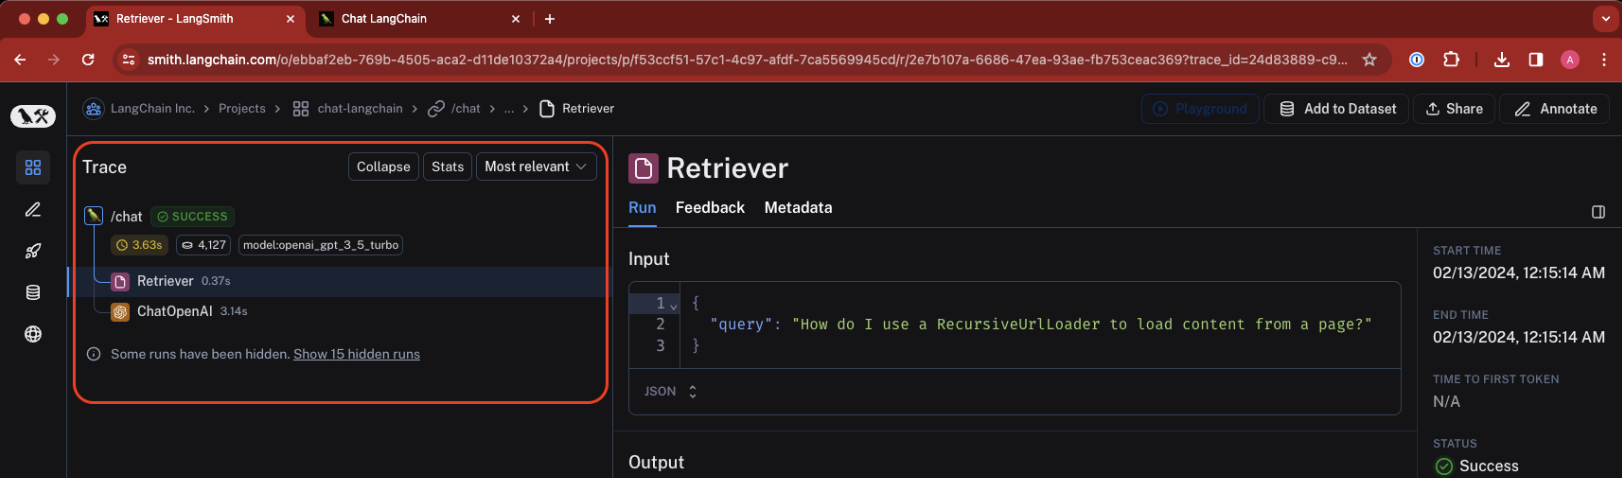

### Run
- Run은 LLM 애플리케이션 내에서 단일 작업 또는 운영 단위를 나타내는 범위입니다.
- 이는 LLM 또는 체인에 대한 단일 호출, 프롬프트 형식 지정 호출, 실행 가능한 람다 호출 등 무엇이든 될 수 있습니다.

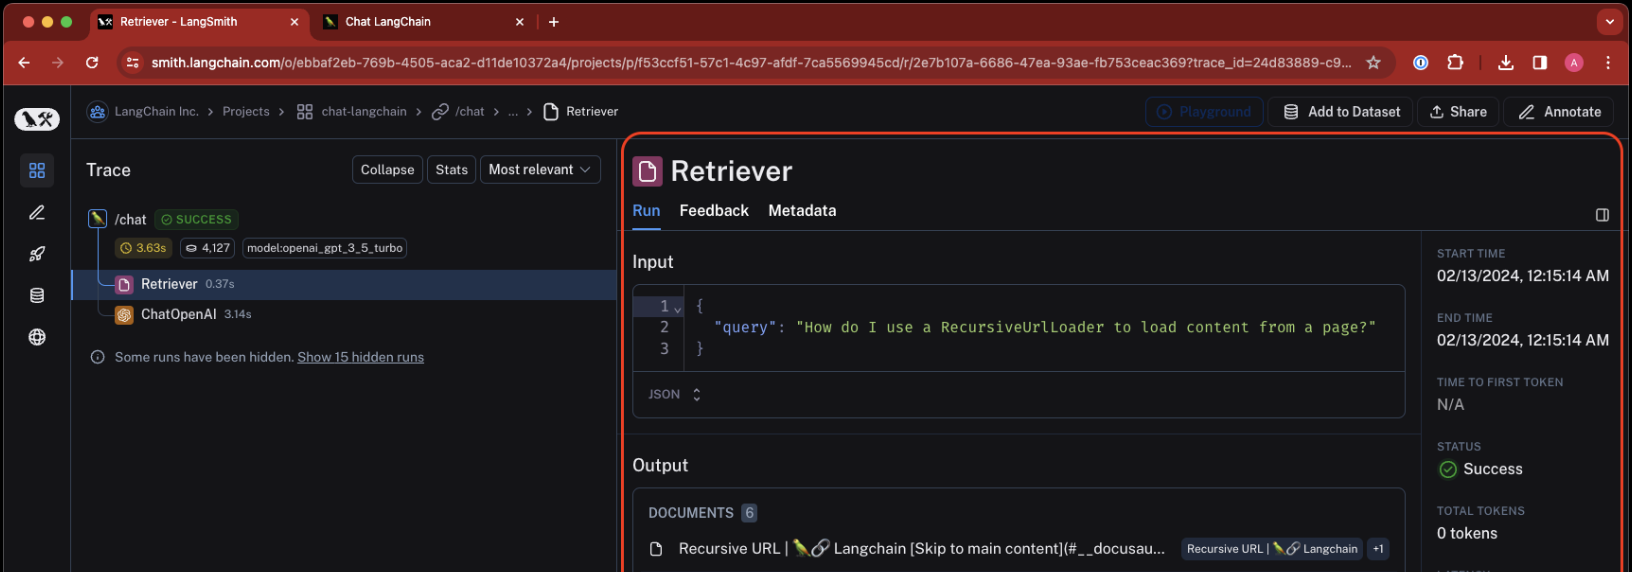

## Langsmith API Key

### [API Key 생성하기](https://smith.langchain.com/)

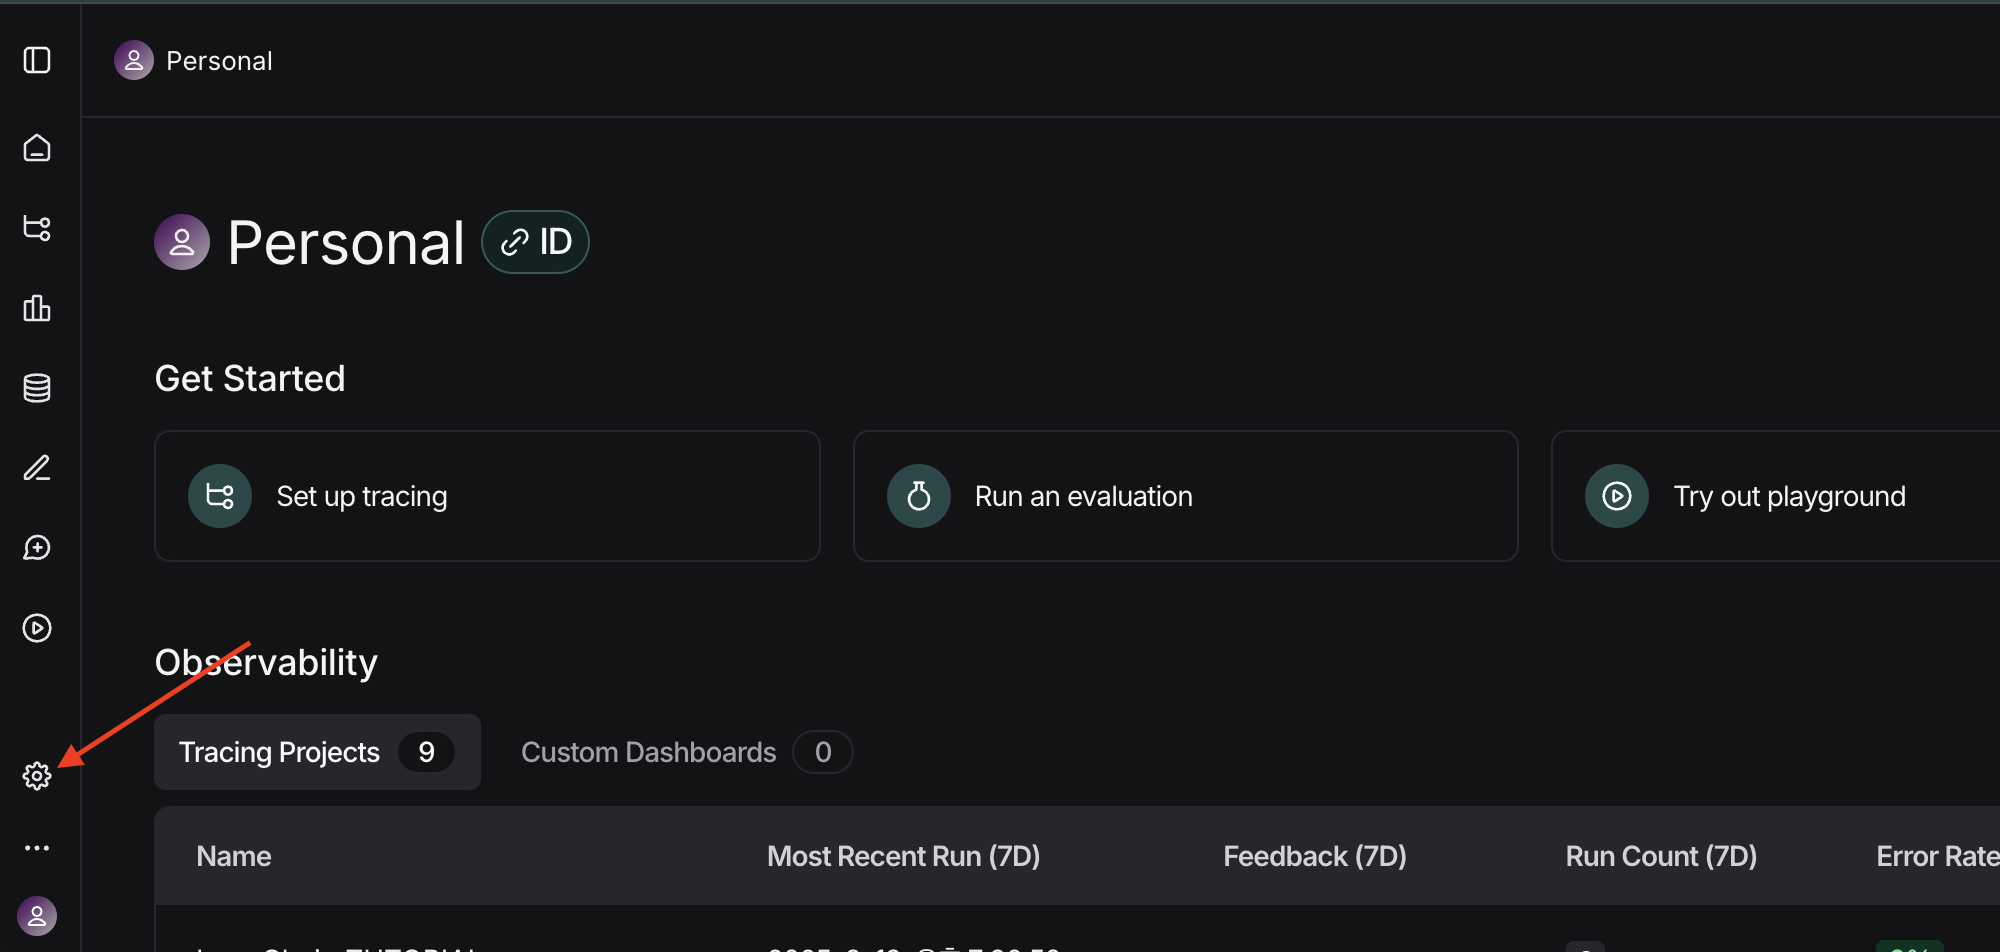

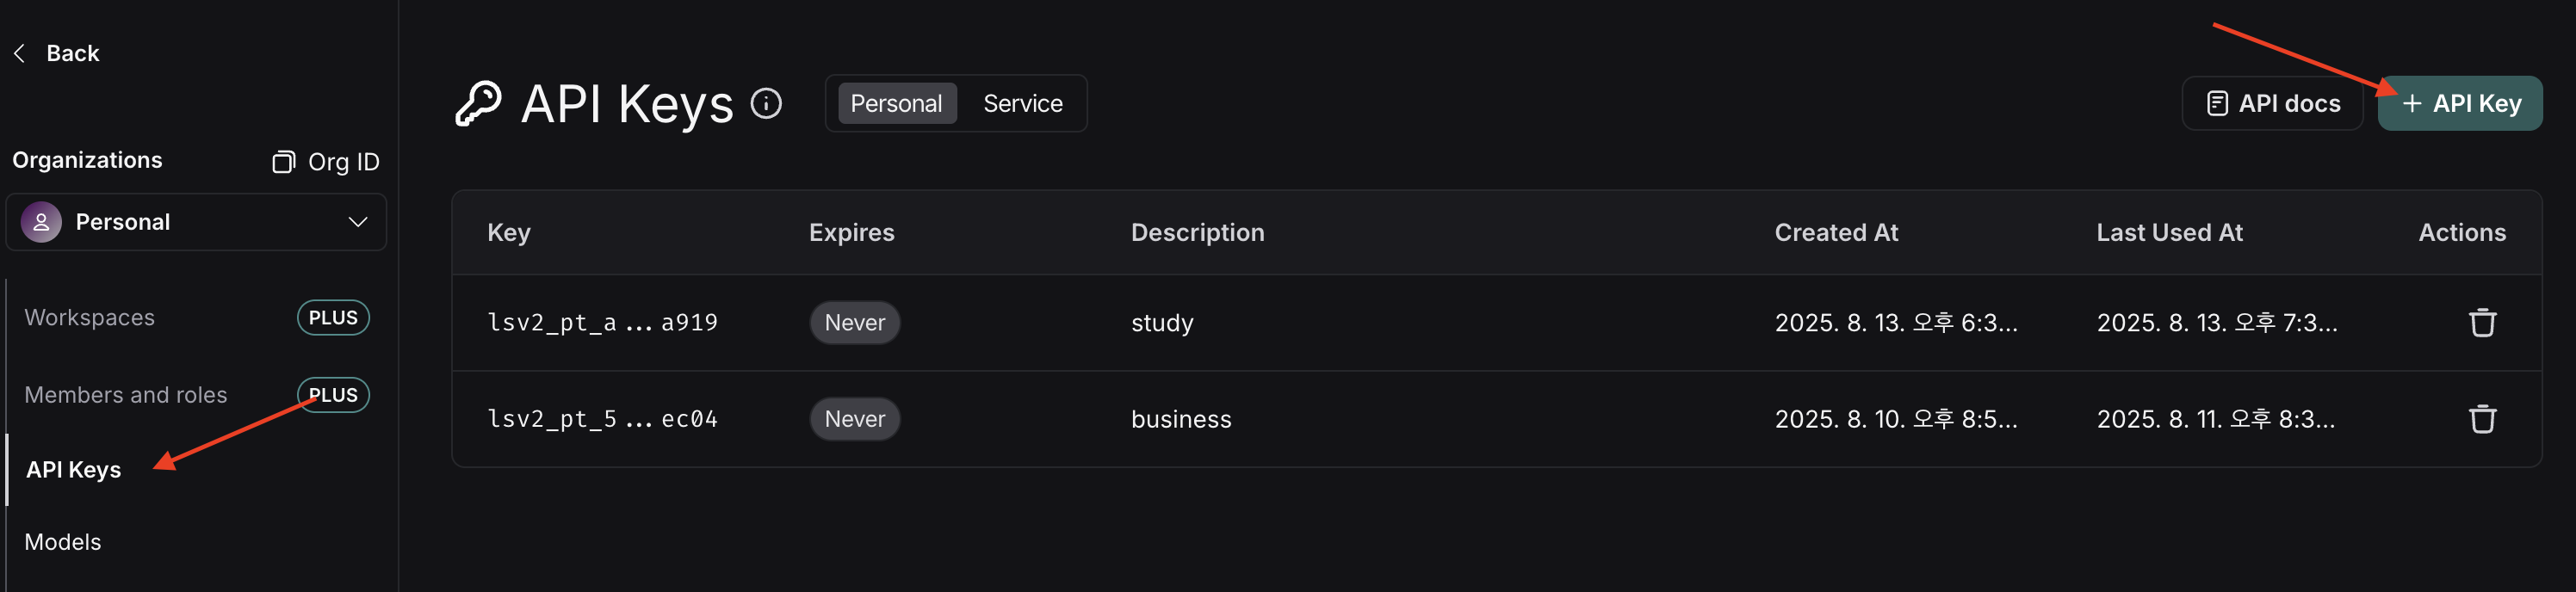

## Langsmith 설정
- LANGCHAIN_TRACING_V2: "true" 로 설정하면 추적을 시작합니다.
- LANGCHAIN_ENDPOINT: https://api.smith.langchain.com 변경하지 않습니다.
- LANGCHAIN_API_KEY: 이전 단계에서 발급받은 키 를 입력합니다.
- LANGCHAIN_PROJECT: 프로젝트 명 을 기입하면 해당 프로젝트 그룹으로 모든 실행(Run) 이 추적됩니다.

# Setup

## 환경변수 로드

In [ ]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

## Groq LLM 설정

In [ ]:
from langchain_groq import ChatGroq

# LLM 모델 설정
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=1.2,
    model_kwargs={
        "top_p":0.9,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.7,         # 반복 억제
        "presence_penalty":0.6,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

# LCEL Chain 예시
- Prompt | Model | OutputParser

## Prompt Template 생성

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage
from langchain_core.prompts import HumanMessagePromptTemplate

prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content="당신은 친절한 AI 어시스턴트입니다."),
    HumanMessagePromptTemplate.from_template("다음 주제에 대해 간단히 설명해주세요: {topic}")
])

prompt.input_variables

['topic']

## LCEL Chain 생성

In [ ]:
from langchain_core.output_parsers import StrOutputParser

chain = prompt | llm | StrOutputParser()

## Chain 실행

In [6]:
result = chain.invoke({"topic": "인공지능"})

print("LCEL Chain 결과:")
print(result)

LCEL Chain 결과:
인공지능(AI)은 인간처럼 학습하고 추론하며 문제를 해결할 수 있도록 컴퓨터와 기계에 지능을 부여하는 기술을 말합니다.  

1️⃣ **기본 개념**  
- **학습(Learning)**: 데이터를 통해 패턴을 찾아 스스로 성능을 개선함.  
- **추론(Reasoning)**: 학습한 지식을 바탕으로 새로운 상황에 적용해 결론을 도출함.  
- **자연어 처리(NLP)**, **이미지·영상 인식**, **음성 인식** 등 다양한 분야에 활용됩니다.  

2️⃣ **주요 유형**  
- **규칙 기반 AI**: 사전에 정의된 규칙으로 작동(예: 전문가 시스템).  
- **머신러닝**: 데이터를 통해 모델을 훈련, 예측·분류 수행.  
- **딥러닝**: 신경망(특히 다층 구조)을 이용해 복잡한 패턴을 학습, 이미지·음성·번역 등에서 뛰어난 성능.  

3️⃣ **실생활 활용 예**  
- 스마트 스피커·챗봇: 음성 인식·대화.  
- 추천 시스템: 온라인 쇼핑·영상 스트리밍에서 맞춤형 콘텐츠 제공.  
- 의료 진단 보조: 이미지 분석·질병 예측.  
- 자율주행 차: 주변 환경 인식·경로 계획.  

4️⃣ **미래 전망**  
AI는 자동화와 생산성 향상을 이끌어 산업 전반을 변화시킬 것으로 기대됩니다. 동시에 **윤리·프라이버시**, **편향(bias) 문제** 등 사회적·법적 과제도 함께 논의되고 있습니다.  

요약하면, 인공지능은 “학습하고, 생각하고, 행동하는” 기계를 만들기 위한 과학·공학 분야이며, 현재 우리의 일상과 다양한 산업에 깊이 스며들어 꾸준히 발전하고 있습니다.


## [Langsmith에서 확인하기](https://smith.langchain.com/)

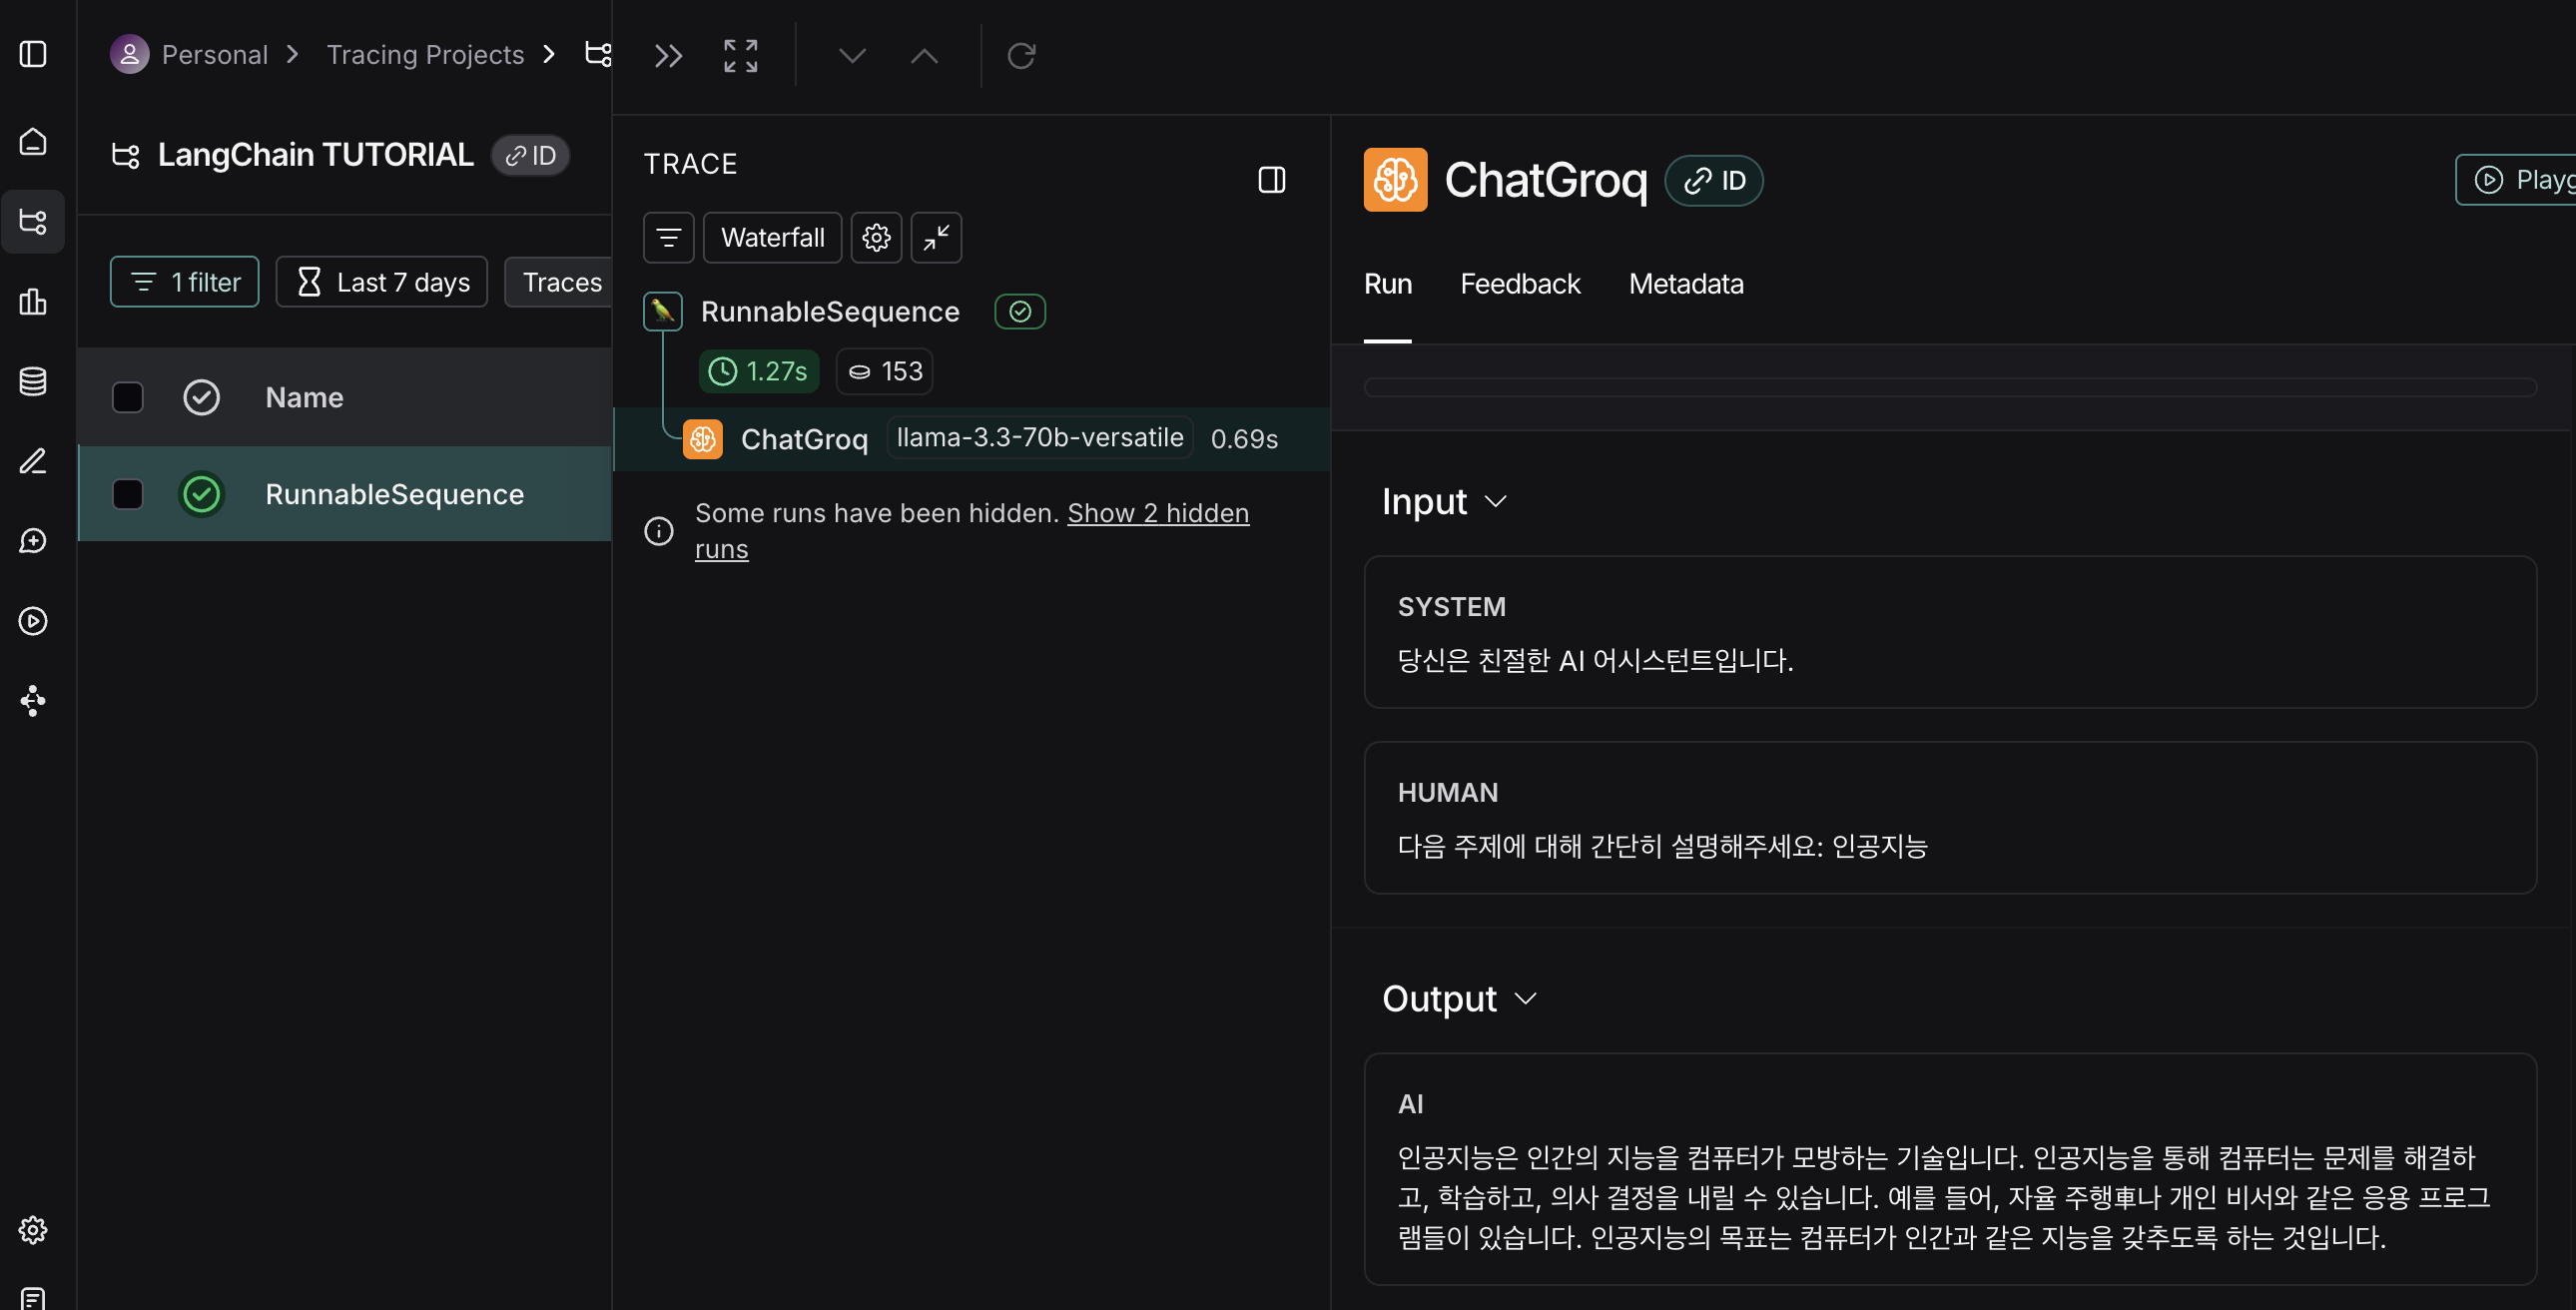